#**Load Data**

In [ ]:
import zipfile
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/FML/images_rgb.zip /content/
!cp /content/drive/MyDrive/FML/test_list.txt test_list.txt
!cp /content/drive/MyDrive/FML/train_val_list.txt train_val_list.txt
!cp /content/drive/MyDrive/FML/Data_Entry_2017.csv Data_Entry_2017.csv

cp: cannot stat '/content/drive/MyDrive/FML/Data_Entry_2017_v2020.csv': No such file or directory


In [ ]:
with zipfile.ZipFile('/content/images_rgb.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/images')

#**Setup**

In [ ]:
import os, csv, random, time
from pathlib import Path
from typing import List, Dict

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.utils.data import WeightedRandomSampler
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score

In [ ]:
ROOT = Path("/content")   # contains images_*/images, split txts, labels CSV
TEST_LIST = ROOT / "test_list.txt"
TRAINVAL_LIST = ROOT / "train_val_list.txt"
LABELS_CSV = ROOT / "Data_Entry_2017.csv"

In [ ]:
# Mode:
# -1 => fine-tune (pretrained backbone, only head new)
#  0..6 => freeze first N groups; random re-init the rest + head
NUM_FROZEN_GROUPS = 6

In [ ]:
BATCH_SIZE   = 64
EPOCHS       = 12
LR           = 1e-3
NUM_WORKERS  = 2
VAL_SPLIT    = 0.1
SEED         = 1337
THRESH       = 0.5  # exact-match threshold for multilabel

In [ ]:
# NIH 14 classes
CLASSES = [
    "Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule",
    "Pneumonia","Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis",
    "Pleural_Thickening","Hernia"
]
IDX = {c:i for i,c in enumerate(CLASSES)}

In [ ]:
# Derived output filenames
mode_tag  = "finetune" if NUM_FROZEN_GROUPS < 0 else f"frozen_{NUM_FROZEN_GROUPS}"
CKPT_BEST = ROOT / f"resnet50_{mode_tag}_best.pt"
CKPT_LAST = ROOT / f"resnet50_{mode_tag}_last.pt"
LOG_CSV   = ROOT / f"metrics_{mode_tag}.csv"
PLOT_LOSS = ROOT / f"curves_{mode_tag}_loss.png"
PLOT_ACC  = ROOT / f"curves_{mode_tag}_acc.png"

In [ ]:
# Reproducibility
random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#**Data utils + Dataset**

In [ ]:
def build_name_to_path(root: Path) -> Dict[str, Path]:
    mapping = {}
    for p in root.glob("images/images_*/images/*.png"):
        mapping[p.name] = p
    return mapping

def load_split(path: Path):
    with open(path) as f:
        return [l.strip() for l in f if l.strip()]

def load_labels(csv_path: Path) -> Dict[str, List[int]]:
    d = {}
    with open(csv_path, newline="") as f:
        rdr = csv.DictReader(f)
        for row in rdr:
            fname = row["Image Index"].strip()
            labs = row["Finding Labels"].strip()
            vec = [0]*len(CLASSES)
            if labs != "No Finding":
                for lab in labs.split("|"):
                    if lab in IDX: vec[IDX[lab]] = 1
            d[fname] = vec
    return d


In [ ]:
class NIHDataset(Dataset):
    def __init__(self, names, name2path, name2label, train):
        self.names, self.name2path, self.name2label, self.train = names, name2path, name2label, train
        self.tf_train = transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
        self.tf_eval = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        n = self.names[i]
        x = Image.open(self.name2path[n]).convert("RGB")
        x = self.tf_train(x) if self.train else self.tf_eval(x)
        y = torch.tensor(self.name2label[n], dtype=torch.float32)
        return x, y, n

#**Model builder (freeze + random re-init)**

In [ ]:
def kaiming_reinit_(m: nn.Module):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None: nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

def freeze_and_reinit(model: models.ResNet, num_frozen_groups: int):
    """
    - num_frozen_groups == -1: fine-tune all backbone (keep pretrained), head is new+random
    - num_frozen_groups in [0..6]:
        * Freeze first N groups (keep pretrained, frozen)
        * Random re-init remaining groups (set trainable)
        * Replace & random-init head
    Groups order: conv1, bn1, layer1, layer2, layer3, layer4
    """
    GROUPS = ["conv1", "bn1", "layer1", "layer2", "layer3", "layer4"]

    # Head (always new, random, trainable)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, len(CLASSES))
    kaiming_reinit_(model.fc)

    if num_frozen_groups < 0:
        for p in model.parameters(): p.requires_grad = True
        return

    nfg = max(0, min(len(GROUPS), num_frozen_groups))
    to_freeze = set(GROUPS[:nfg])
    # Freeze selected groups
    for name, module in model.named_children():
        if name in to_freeze:
            for p in module.parameters(): p.requires_grad = False

    # Random re-init the rest and make trainable
    for name in GROUPS[nfg:]:
        module = getattr(model, name)
        # module.apply(kaiming_reinit_)
        for p in module.parameters(): p.requires_grad = True


#**Build loaders**

##1. prepare for loaders

In [ ]:
# Index disk + load splits + labels
name2path   = build_name_to_path(ROOT)
test_names  = load_split(TEST_LIST)
trainval    = load_split(TRAINVAL_LIST)
name2label  = load_labels(LABELS_CSV)
print('===========')
# Keep only items present on disk and in labels
def filt(xs): return [n for n in xs if n in name2path and n in name2label]
test_names  = filt(test_names)
trainval    = filt(trainval)
print("------------")
# Split train/val
random.shuffle(trainval)
v = max(1, int(len(trainval)*VAL_SPLIT))
val_names, train_names = trainval[:v], trainval[v:]
print(f"Train {len(train_names)} | Val {len(val_names)} | Test {len(test_names)}")


------------
Train 77871 | Val 8652 | Test 25596


##2. Create loaders

In [ ]:
train_dl = DataLoader(NIHDataset(train_names, name2path, name2label, train=True),
                      batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
val_dl   = DataLoader(NIHDataset(val_names, name2path, name2label, train=False),
                      batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
test_dl  = DataLoader(NIHDataset(test_names,  name2path, name2label, train=False),
                      batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)

#**Create model + optimizer/scheduler**

##1. Setup loss and optimizers

####I. Load model

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
freeze_and_reinit(model, NUM_FROZEN_GROUPS)
model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


####II. Create optimizer, criterion and LR shedular

In [ ]:
optim_params = (p for p in model.parameters() if p.requires_grad)
optimizer = torch.optim.AdamW(optim_params, lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
criterion = nn.BCEWithLogitsLoss()

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Trainable parameters: 28686


#**Train/Eval loops (saves best+last every epoch; logs for plotting)**

In [ ]:
@torch.no_grad()
def compute_auroc(model, loader, device, class_names=CLASSES):
    model.eval()
    ys, ps = [], []
    for x, y, _ in loader:
        x = x.to(device)
        logits = model(x)
        ps.append(torch.sigmoid(logits).cpu())
        ys.append(y)

    y_true = torch.vstack(ys).numpy()   # [N, C]
    y_prob = torch.vstack(ps).numpy()   # [N, C]

    per_class = {}
    for c, name in enumerate(class_names):
        y_c = y_true[:, c]
        p_c = y_prob[:, c]
        # Need at least one positive and one negative to compute AUROC
        if (y_c.sum() > 0) and ((1 - y_c).sum() > 0):
            try:
                per_class[name] = roc_auc_score(y_c, p_c)
            except Exception:
                per_class[name] = np.nan
        else:
            per_class[name] = np.nan

    mean_auc = float(np.nanmean(list(per_class.values())))
    return per_class, mean_auc

## Validation
@torch.no_grad()
def run_eval(loader):
    model.eval()
    n, lsum, asum = 0, 0.0, 0.0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        acc  = exact_match_acc_from_logits(logits, y)
        lsum += loss.item()*x.size(0)
        asum += acc * x.size(0)
        n += x.size(0)
    return lsum/n, asum/n


def exact_match_acc_from_logits(logits, y, thresh=THRESH):
    pred = (torch.sigmoid(logits) >= thresh).float()
    return (pred.eq(y).all(dim=1).float().mean().item())


In [ ]:
# history for plots
hist = {"epoch": [],
        "train_loss": [], "val_loss": [], "test_loss": [],
        "val_auroc": [],  "test_auroc": []}

best_val = float("inf")

# CSV header
if not LOG_CSV.exists():
    with open(LOG_CSV, "w", newline="") as f:
        csv.writer(f).writerow(["epoch","train_loss","train_acc","val_loss","val_acc","val_auroc"])

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    n, loss_sum, acc_sum = 0, 0.0, 0.0
    for x, y, _ in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            acc = exact_match_acc_from_logits(logits, y)
        loss_sum += loss.item()*x.size(0)
        acc_sum += acc * x.size(0)
        n += x.size(0)
    scheduler.step()
    train_loss, train_acc = loss_sum/n, acc_sum/n

    # Evaluation
    val_loss,  val_acc  = run_eval(val_dl)
    val_auc_per_class,  val_auc_mean  = compute_auroc(model, val_dl,  device)

    # Log history
    hist["epoch"].append(epoch)
    hist["train_loss"].append(train_loss); hist["train_acc"].append(train_acc)
    hist["val_loss"].append(val_loss);     hist["val_acc"].append(val_acc)
    hist["val_auroc"].append(val_auc_mean)

    # Save last every epoch
    torch.save({"model": model.state_dict(), "classes": CLASSES, "mode": mode_tag, "epoch": epoch}, CKPT_LAST)

    # Save best by val loss
    if val_loss < best_val:
        best_val = val_loss
        torch.save({"model": model.state_dict(), "classes": CLASSES, "mode": mode_tag, "epoch": epoch}, CKPT_BEST)
        print(f"✓ Saved new best to {CKPT_BEST}")

    # Append to CSV
    with open(LOG_CSV, "a", newline="") as f:
        csv.writer(f).writerow([epoch, train_loss, train_acc, val_loss, val_acc, val_auc_mean])

    dt = time.time() - t0
    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={train_loss:.6f} acc={train_acc:.6f} | "
          f"val_loss={val_loss:.6f} acc={val_acc:.6f}  AUROC={val_auc_mean:.6f}| ({dt:.1f}s)")

print(f"\nSaved checkpoints:\n  - best: {CKPT_BEST}\n  - last: {CKPT_LAST}\nLogs: {LOG_CSV}")


✓ Saved new best to /content/resnet50_frozen_6_best.pt
[01/12] train_loss=0.1601 acc=0.582 | val_loss=0.1524 acc=0.586  AUROC=0.692| test_loss=0.2366 acc=0.383 AUROC=0.662 (512.0s)
✓ Saved new best to /content/resnet50_frozen_6_best.pt
[02/12] train_loss=0.1506 acc=0.583 | val_loss=0.1505 acc=0.584  AUROC=0.716| test_loss=0.2342 acc=0.382 AUROC=0.681 (484.4s)
✓ Saved new best to /content/resnet50_frozen_6_best.pt
[03/12] train_loss=0.1482 acc=0.583 | val_loss=0.1502 acc=0.584  AUROC=0.723| test_loss=0.2343 acc=0.379 AUROC=0.687 (469.9s)
✓ Saved new best to /content/resnet50_frozen_6_best.pt
[04/12] train_loss=0.1468 acc=0.583 | val_loss=0.1499 acc=0.584  AUROC=0.727| test_loss=0.2340 acc=0.378 AUROC=0.689 (474.0s)
✓ Saved new best to /content/resnet50_frozen_6_best.pt
[05/12] train_loss=0.1456 acc=0.583 | val_loss=0.1496 acc=0.585  AUROC=0.728| test_loss=0.2339 acc=0.380 AUROC=0.691 (476.4s)
✓ Saved new best to /content/resnet50_frozen_6_best.pt
[06/12] train_loss=0.1448 acc=0.583 | va

#**Plots (Test loss, Test accuracy; also show train/val/AUCROC for context)**

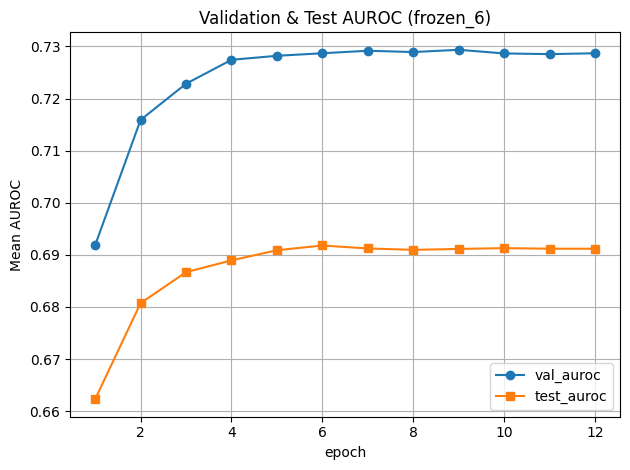

Saved AUROC plot:
 - /content/curves_frozen_6_auroc.png


In [ ]:
# AUROC curves (Validation and Test)
epochs = hist["epoch"]
plt.figure()
plt.plot(epochs, hist["val_auroc"],  label="val_auroc")
plt.xlabel("epoch")
plt.ylabel("Mean AUROC")
plt.title(f"Validation & Test AUROC ({mode_tag})")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save figure
PLOT_AUROC = ROOT / f"curves_{mode_tag}_auroc.png"
plt.savefig(PLOT_AUROC)
plt.show()

print(f"Saved AUROC plot:\n - {PLOT_AUROC}")


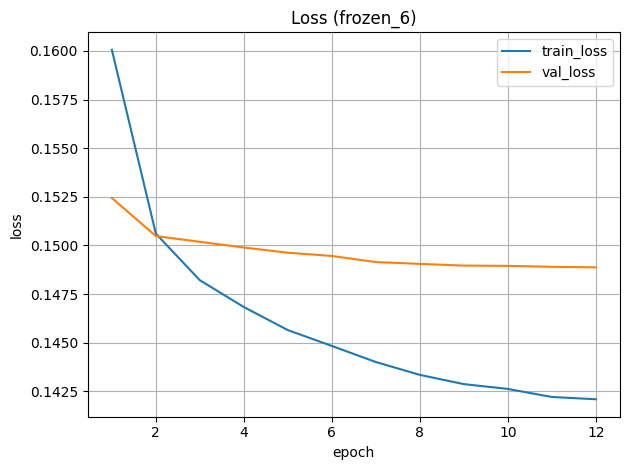

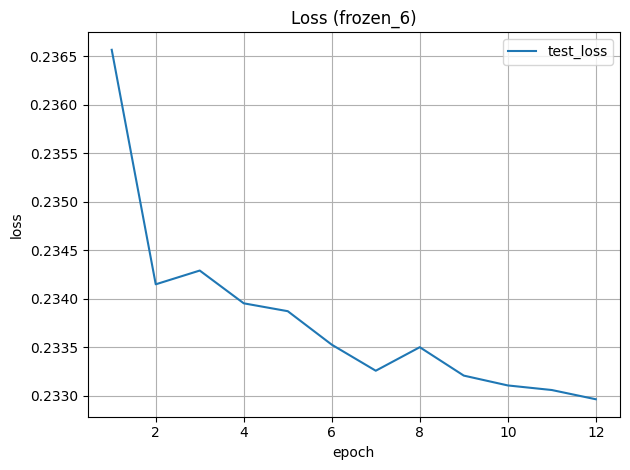

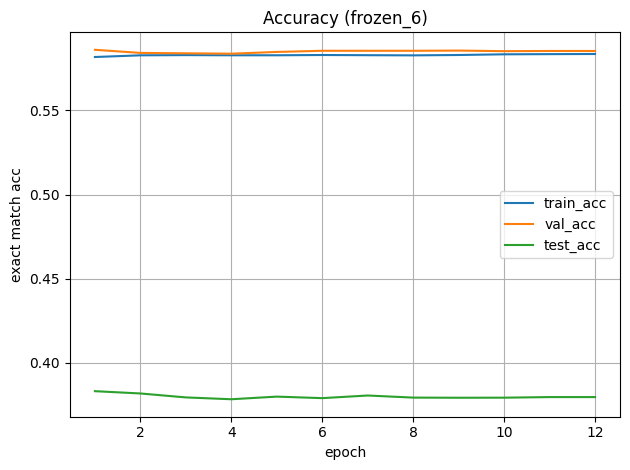

Saved plots:
 - /content/curves_frozen_6_loss.png
 - /content/curves_frozen_6_acc.png


In [ ]:
epochs = hist["epoch"]

# Loss curves
plt.figure()
plt.plot(epochs, hist["train_loss"], label="train_loss")

plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"Loss ({mode_tag})"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_LOSS)
plt.show()
plt.figure()
plt.plot(epochs, hist["val_loss"],   label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"Loss ({mode_tag})"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(PLOT_LOSS)
plt.show()

print(f"Saved plots:\n - {PLOT_LOSS}\n - {PLOT_ACC}")


#  Load Best Model & Evaluate on Test Set

In [ ]:
import pandas as pd

###1. Create Metrics Directory



In [ ]:
METRICS_DIR = ROOT / "metrics"
os.makedirs(METRICS_DIR, exist_ok=True)

###2. Load best model

In [ ]:
ckpt = torch.load(CKPT_BEST, map_location=device)
model.load_state_dict(ckpt["model"])
model = model.to(device)
model.eval()
print(f"Loaded best model from {CKPT_BEST}")

Loaded best model from /content/resnet50_frozen_6_best.pt


###3. Evaluate on test set

In [ ]:
test_loss = 0.0
correct = 0
total = 0
all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels, _ in test_dl:   # (x, y, name) from NIHDataset
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)
        test_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = probs > THRESH  # using global threshold (0.5)

        # element-wise accuracy over all lables
        correct += (preds == labels.bool()).sum().item()
        total += labels.numel()

        all_labels.append(labels.cpu())
        all_probs.append(probs.cpu())

test_loss /= len(test_dl)
test_accuracy = correct / total

all_labels = torch.cat(all_labels).numpy()
all_probs = torch.cat(all_probs).numpy()

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy (per-label): {test_accuracy:.4f}")

Test Loss: 0.5318
Test Accuracy (per-label): 0.7252


###4. Per-class and macro AUC

In [ ]:
class_aucs = []
num_classes = all_labels.shape[1]

for i in range(num_classes):
    y_true_c = all_labels[:, i]
    y_prob_c = all_probs[:, i]
    try:
        auc = roc_auc_score(y_true_c, y_prob_c)
    except ValueError:
        auc = float("nan")  # class might have no positives or no negatives
    class_aucs.append(auc)

macro_auc = float(np.nanmean(class_aucs))

print("\nPer-class ROC-AUC:")
for idx, auc in enumerate(class_aucs):
    cls_name = CLASSES[idx] if idx < len(CLASSES) else f"class_{idx}"
    print(f"Class {idx:2d} ({cls_name:20s}): {auc:.4f}")

print(f"\nMacro ROC-AUC: {macro_auc:.4f}")


Per-class ROC-AUC:
Class  0 (Atelectasis         ): 0.6563
Class  1 (Cardiomegaly        ): 0.7245
Class  2 (Effusion            ): 0.7132
Class  3 (Infiltration        ): 0.6389
Class  4 (Mass                ): 0.6462
Class  5 (Nodule              ): 0.6321
Class  6 (Pneumonia           ): 0.5983
Class  7 (Pneumothorax        ): 0.7412
Class  8 (Consolidation       ): 0.6662
Class  9 (Edema               ): 0.7667
Class 10 (Emphysema           ): 0.7409
Class 11 (Fibrosis            ): 0.7406
Class 12 (Pleural_Thickening  ): 0.6722
Class 13 (Hernia              ): 0.7867

Macro ROC-AUC: 0.6946


###5. Save true & predicted results of test set

In [ ]:
test_pred_csv = METRICS_DIR / f"test_predictions_{mode_tag}.csv"

df = pd.DataFrame({
    **{f"true_{i}": all_labels[:, i].astype(int) for i in range(num_classes)},
    **{f"prob_{i}": all_probs[:, i] for i in range(num_classes)}
})

df.to_csv(test_pred_csv, index=False)
print(f"Saved test predictions to {test_pred_csv}")

Saved test predictions to /content/metrics/test_predictions_frozen_6.csv


###6. Save final test metrics

In [ ]:
results_csv = METRICS_DIR / f"final_results_{mode_tag}.csv"
file_exists = results_csv.exists()

with open(results_csv, "a") as f:
    if not file_exists:
        f.write(
            "test_loss,test_accuracy,macro_auc," +
            ",".join([f"class_{i}_auc" for i in range(num_classes)]) +
            "\n"
        )

    f.write(
        f"{test_loss:.4f},{test_accuracy:.4f},{macro_auc:.4f}," +
        ",".join([f"{auc:.4f}" for auc in class_aucs]) +
        "\n"
    )

print(f"Saved final test metrics to {results_csv}")

Saved final test metrics to /content/metrics/final_results_frozen_6.csv
